In [25]:
#Used the following pytorch documentation and links to get more familiar with defining RNN:
#https://codingnomads.com/create-rnn-from-scratch-tutorial
#https://deeplearningnotes.com/rnns-attention/rnns-basics/vanilla-rnn
#https://calvinfeng.gitbook.io/machine-learning-notebook/supervised-learning/recurrent-neural-network/recurrent_neural_networks

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

## Load the data

`X_train`/`X_test` are lists of variable-length sequences (each a `(seq_len, 10)` tensor); `y_train`/`y_test` are the corresponding scalar targets. Make sure `X_train.npy`, `y_train.npy`, `X_test.npy`, and `y_test.npy` (from `homework4_question2_data.zip`) are in the same directory as this notebook before running the cell below.

In [27]:
dataset_dir = '/Users/pegah/Projects/DS:CS541/HW4/Problem2'

# load training and test data
def loadData():
    X_train = np.load(os.path.join(dataset_dir, 'X_train.npy'), allow_pickle=True)
    y_train = np.load(os.path.join(dataset_dir, 'y_train.npy'), allow_pickle=True)
    X_test = np.load(os.path.join(dataset_dir, 'X_test.npy'), allow_pickle=True)
    y_test = np.load(os.path.join(dataset_dir, 'y_test.npy'), allow_pickle=True) 

    X_train = [torch.Tensor(x) for x in X_train]  # List of Tensors (SEQ_LEN[i], INPUT_DIM) i=0..NUM_SAMPLES-1
    X_test = [torch.Tensor(x) for x in X_test]  # List of Tensors (SEQ_LEN[i], INPUT_DIM)
    y_train = torch.Tensor(y_train)  # (NUM_SAMPLES, 1)
    y_test = torch.Tensor(y_test)  # (NUM_SAMPLES, 1)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = loadData()
device = y_train.device

## Task 1 (4 points): Implement a Vanilla RNN

Implement a Vanilla RNN architecture by hand (weights are shared across time steps). **You are not allowed to use an RNN layer implementation from any library** (e.g. `nn.RNN`, `nn.RNNCell`) -- only basic layers like `nn.Linear`.

In [28]:
# Define a Vanilla RNN layer by hand
class RNNLayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(RNNLayer, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        # BEGIN YOUR CODE HERE (~3 lines)
        # Define the input-to-hidden weights (W_xh), hidden-to-hidden
        # weights (W_hh), and the activation function applied to their
        # combined output (a Vanilla RNN uses tanh).
        #ht=wx+wht-1
        #input to hodden
        self.W_xh = nn.Linear(input_size,hidden_size)
        #hidden to hidden
        self.W_hh = nn.Linear(hidden_size,hidden_size)
        #using tanh
        self.activation =nn.Tanh() 
        # END YOUR CODE HERE

    def forward(self, x, hidden):
        # BEGIN YOUR CODE HERE (~1 line)
        # Combine the current input x and the previous hidden state,
        # then apply the activation function.
                                #current input x and previous hidden state
        hidden =self.activation(self.W_xh(x)+self.W_hh(hidden))
        # END YOUR CODE HERE
        return hidden 


# Define a sequence prediction model using the Vanilla RNN
class SequenceModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SequenceModel, self).__init__()
        self.hidden_size = hidden_size
        # BEGIN YOUR CODE HERE (~2 lines)
        self.rnn = RNNLayer(input_size,hidden_size) #defining the RNN for mapping input to hidden layer
        self.linear = nn.Linear(hidden_size,output_size) #defining the linear layer for mapping last hidden state to output
        # END YOUR CODE HERE

    def forward(self, input_seq, seq_lengths):
        # BEGIN YOUR CODE HERE (~2 lines)
        # input_seq is a list of (seq_len_b, input_size) tensors, one per
        # sample in the batch (lengths may differ across samples).
        batch_size =len(input_seq)  # length of the list of tensors we have in input_seq
        # last hidden state 
        last_hidden = torch.zeros(batch_size, self.hidden_size).to(device) 
        # END YOUR CODE HERE

        for b in range(batch_size):
            hidden = torch.zeros(self.hidden_size).to(device)

            # BEGIN YOUR CODE HERE (~3 lines)
            # Run the RNN layer forward, one timestep at a time, over
            # this sample's full sequence (its own seq_lengths[b] steps),
            # updating `hidden` each step.
            seq_length =seq_lengths[b]  #seq length
            for t in range(seq_length):   #batch b at time t
                hidden = self.rnn(input_seq[b][t], hidden) 
            # END YOUR CODE HERE

            # Store the last hidden state in the output tensor
            last_hidden[b] =hidden 

        output = self.linear(last_hidden)
        return output

## Tasks 2 & 3 (4 points each): Fixed-length variants

`SequenceModelFixedLen` below is shared by both variants -- it is instantiated with `seq_len` set to the dataset's shortest sequence length for **Task 2 (truncated)**, and to the dataset's longest sequence length for **Task 3 (padded)**. Unlike `SequenceModel` above, each timestep gets its **own, non-shared** `RNNLayer` (`self.rnn_layers[t]`), so this model does not tie weights across time.

The constructor parameter `seq_len` is what caps how many timesteps of each sequence actually get processed: in `forward`, each sample only runs for `min(self.seq_len, seq_lengths[b])` steps, i.e. its own length, but never more than `seq_len`. Setting `seq_len` to the shortest training-sequence length (Task 2) therefore truncates every longer sequence down to that length. Setting `seq_len` to the longest sequence length (Task 3) never truncates anything -- every sample simply runs its own true length, which is exactly what "ignoring the padding" amounts to here (a shorter sample never reaches, let alone runs, the extra padded timesteps).

In [29]:
# Define a sequence prediction model for fixed length sequences, BUT NO SHARED WEIGHTS
class SequenceModelFixedLen(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, seq_len):
        super(SequenceModelFixedLen, self).__init__()
        self.hidden_size = hidden_size
        self.seq_len = seq_len
        # BEGIN YOUR CODE HERE (~2 lines)
        # Note: rnn_layers is wrapped in nn.ModuleList (not a plain
        # Python list) -- nn.Module only auto-registers submodules held
        # in its own attributes/containers like nn.ModuleList, so a bare
        # list here would make every one of these RNNLayers invisible to
        # model.parameters(), and the optimizer would silently never
        # update them.
        self.rnn_layers = nn.ModuleList([RNNLayer(input_size,hidden_size) for _ in range(seq_len)]) #defining the RNN
        self.linear = nn.Linear(hidden_size,output_size) #defining the linear layer for mapping last hidden state to output
        # END YOUR CODE HERE

    def forward(self, input_seq, seq_lengths):
        batch_size = len(input_seq)
        last_hidden = torch.zeros(batch_size, self.hidden_size).to(device)

        for b in range(batch_size):
            hidden = torch.zeros(self.hidden_size).to(device)

            # BEGIN YOUR CODE HERE (~3 lines)
            # For Task 2 (truncated), self.seq_len is the shortest
            # sequence length, so every sample runs for exactly
            # self.seq_len steps. 
            # 
            # For Task 3 (padded), self.seq_len is
            # the longest sequence length; a sample shorter than that
            # should stop at its OWN true length (min(...) below handles
            # both cases -- this is your "ignore the padding" mechanism,
            # since a shorter sample simply never runs its remaining,
            # nonexistent timesteps).
            #seq length would be the minimum of seq_len and actual length of the seq for a batch
            seq_length = min(self.seq_len,seq_lengths[b]) 
            for t in range(seq_length):
                # runninng the forward pass for this RNN for input at time t and batch b and updating hidden
                hidden =self.rnn_layers[t](input_seq[b][t], hidden)
            # END YOUR CODE HERE

            # Store the last hidden state in the output tensor
            last_hidden[b] = hidden

        output = self.linear(last_hidden)
        return output

## Hyperparameters and training loop

In [ ]:
# Define hyperparameters and other settings
input_size = 10  # Replace with the actual dimension of your input features
hidden_size = 64
output_size = 1
num_epochs = 20 #10
learning_rate = 0.0001 #0.001
batch_size = 64 #32

# Sequence lengths across the training set -- needed to pick seq_len for
# the Task 2 (shortest) and Task 3 (longest) SequenceModelFixedLen models.
seq_lengths = [seq.shape[0] for seq in X_train]
min_length = min(seq_lengths)
max_length = max(seq_lengths)

In [31]:

min_length

5

In [32]:
max_length

20

In [33]:
# Training loop
def train(model, num_epochs, lr, batch_size, X_train, y_train, seq_lengths):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Task 4 asks you to "monitor and record the training ... loss
    # curves" -- record the average loss per epoch here so you can plot
    # it later (see the plotting cell under Task 4).
    epoch_losses = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        num_batches = 0
        for i in range(0, len(X_train), batch_size):
            inputs = X_train[i:i + batch_size]
            targets = y_train[i:i + batch_size]
            lengths = seq_lengths[i:i + batch_size]

            optimizer.zero_grad()
            outputs = model(inputs, lengths)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        epoch_loss = running_loss / num_batches
        epoch_losses.append(epoch_loss)
        print(f'Epoch {epoch + 1}, Loss: {epoch_loss}')
    return model, epoch_losses

## Task 4 (4 points): Train all three models, then predict before you evaluate

Train the Vanilla RNN, the truncated (shortest-length) model, and the padded (longest-length) model, each using MSE loss for a fixed number of epochs. Monitor and record the training (and validation, if you set aside a validation split) loss curves for each model. `train(...)` returns `(model, epoch_losses)` -- capture both.

Then, *before* looking at test-set performance, predict the **ranking** of the three models by overall test MSE (best to worst). Justify your prediction using the actual mechanics of the three architectures (shared weights vs. fixed-length truncation vs. fixed-length padding) -- not just intuition.

In [34]:

# BEGIN YOUR CODE HERE
# Initialize and train the Vanilla RNN (SequenceModel).
vanillarnn=SequenceModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
#train model
vanillarnn,epoch_losses=train(vanillarnn, num_epochs, learning_rate, batch_size, X_train, y_train, seq_lengths)
# loss for each epoch
vanillarnn_losses=epoch_losses

# END YOUR CODE HERE

Epoch 1, Loss: 0.038131714726869874
Epoch 2, Loss: 0.02787113719834731
Epoch 3, Loss: 0.020741676052029315
Epoch 4, Loss: 0.015703995855381854
Epoch 5, Loss: 0.01207796262147335
Epoch 6, Loss: 0.009451172601145048
Epoch 7, Loss: 0.007554570750261729
Epoch 8, Loss: 0.006190216634422541
Epoch 9, Loss: 0.005211092030199675
Epoch 10, Loss: 0.0045093376404390885
Epoch 11, Loss: 0.004005678177166443
Epoch 12, Loss: 0.0036421335087372707
Epoch 13, Loss: 0.003376854135869787
Epoch 14, Loss: 0.003180047873264322
Epoch 15, Loss: 0.0030307531571732117
Epoch 16, Loss: 0.002914358915474552
Epoch 17, Loss: 0.002820762080283692
Epoch 18, Loss: 0.0027430295550192776
Epoch 19, Loss: 0.0026764376268077353
Epoch 20, Loss: 0.0026177881876579844


In [35]:
# BEGIN YOUR CODE HERE
# Initialize and train the Sequential NN fixing #timesteps to the
# minimum sequence length (SequenceModelFixedLen with seq_len=min_length).
truncatedrnn=SequenceModelFixedLen(input_size=input_size, hidden_size=hidden_size, output_size=output_size, seq_len=min_length)
#train model
truncatedrnn,epoch_losses=train(truncatedrnn, num_epochs, learning_rate, batch_size, X_train, y_train, seq_lengths)

#loss for each epoch
truncatedrnn_losses=epoch_losses
# END YOUR CODE HERE

Epoch 1, Loss: 0.10225501885780922
Epoch 2, Loss: 0.08652876661374019
Epoch 3, Loss: 0.07432305010465476
Epoch 4, Loss: 0.0645583079984555
Epoch 5, Loss: 0.05664605933886308
Epoch 6, Loss: 0.05013970916087811
Epoch 7, Loss: 0.044703385864312835
Epoch 8, Loss: 0.04009587790530462
Epoch 9, Loss: 0.03614724542085941
Epoch 10, Loss: 0.03273641604643602
Epoch 11, Loss: 0.029774831034816228
Epoch 12, Loss: 0.027195411949203566
Epoch 13, Loss: 0.02494539112712328
Epoch 14, Loss: 0.022981796915141437
Epoch 15, Loss: 0.021268618937868338
Epoch 16, Loss: 0.019775041952156104
Epoch 17, Loss: 0.018474261562984724
Epoch 18, Loss: 0.017342733649107125
Epoch 19, Loss: 0.016359626673735105
Epoch 20, Loss: 0.015506438839320954


In [36]:
# BEGIN YOUR CODE HERE
# Initialize and train the Sequential NN fixing #timesteps to the
# maximum sequence length (SequenceModelFixedLen with seq_len=max_length).
# NOTE: it is OK to use torch.nn.utils.rnn.pad_sequence; make sure to
# set parameter batch_first correctly.
paddedrnn=SequenceModelFixedLen(input_size=input_size, hidden_size=hidden_size, output_size=output_size, seq_len=max_length)
#train model
paddedrnn,epoch_losses=train(paddedrnn, num_epochs, learning_rate, batch_size, X_train, y_train, seq_lengths)

#loss for each epoch
paddedrnn_losses=epoch_losses
# END YOUR CODE HERE

Epoch 1, Loss: 0.12435726190988834
Epoch 2, Loss: 0.10660798561114532
Epoch 3, Loss: 0.09284265969808285
Epoch 4, Loss: 0.08146264977180041
Epoch 5, Loss: 0.07201995127476178
Epoch 6, Loss: 0.06413559644268109
Epoch 7, Loss: 0.05749739849796662
Epoch 8, Loss: 0.05185700981662823
Epoch 9, Loss: 0.04701974615454674
Epoch 10, Loss: 0.04283362469420983
Epoch 11, Loss: 0.03917999694553705
Epoch 12, Loss: 0.03596606334814659
Epoch 13, Loss: 0.033118925702113375
Epoch 14, Loss: 0.030580972392971698
Epoch 15, Loss: 0.028306257122984298
Epoch 16, Loss: 0.026257748930500105
Epoch 17, Loss: 0.02440527009849365
Epoch 18, Loss: 0.02272393575941141
Epoch 19, Loss: 0.0211930088698864
Epoch 20, Loss: 0.019795022618312102


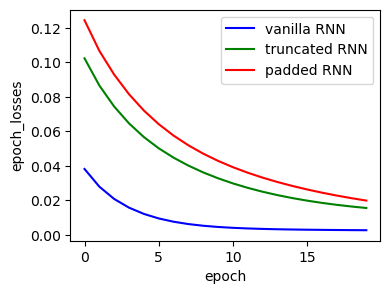

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))

# BEGIN YOUR CODE HERE
# Plot the recorded per-epoch training (and validation) loss curves for
# all three models on the same axes, for comparison.
plt.xlabel("epoch")
plt.ylabel("epoch_losses")

plt.plot(vanillarnn_losses, label='vanilla RNN', color='blue')
plt.plot(truncatedrnn_losses, label='truncated RNN', color='green')
plt.plot(paddedrnn_losses, label='padded RNN', color='red')

#adding legend so we know lines corresponding to the models
plt.legend()

# END YOUR CODE HERE

### Task 4 answer

_Your predictions and justification here._

Based on the task that we trained 3 versions of RNNs (vanilla, truncated, padded), the vanilla verison was using shared weights at each time steps but the truncated and padded ones were not using shared weights. After training for 10 epochs this was the loss result for each model at 10th epoch (ordered from lowest training loss to highest):

- padded:  0.0002
- vanilla:  0.0013
- truncated:  0.005


based on these results, the padded version has the lowest training MSE (0.0002), followed by vanilla (0.0013), and then truncated one (0.005).
The vanilla RNN is a basic RNN wth shared weights across all time steps. Truncated one makes long sequence short by fixing a min length and discarding anything beyond it, and padded version make short sequence longer by putting 0s.  
It makes sense that the truncated version showed higher training loss than the vanilal model as this model truncated info and has less info available. Comparing truncated vs. padded version we can say since padding does not discard any info, it had better training loss compared to the truncated version that discarded anything after a point.

## Task 5 (4 points): Reconcile and analyze

Evaluate all three trained models on the test set and report the overall test MSE for each. Compare the actual ranking to your Task 4 prediction. Where you were right, explain why using the models' mechanics; where you were surprised, propose a concrete explanation. Discuss the trade-offs between shared weights, truncation, and padding for modeling sequences of varying length.

In [38]:
# BEGIN YOUR CODE HERE
# 1. Evaluate each of the three trained models on the test set (X_test,
#    y_test) using MSE. Compute FRESH sequence lengths from X_test
#    itself (e.g. test_seq_lengths = [seq.shape[0] for seq in X_test])
#    -- don't reuse the training set's seq_lengths variable, since it's
#    still in scope but describes the wrong sequences/order entirely.
criterion = nn.MSELoss()
test_seq_lengths = [seq.shape[0] for seq in X_test]
#evaluate models on test set
vanilla_test_outputs = vanillarnn(X_test, test_seq_lengths)
#mse for vanilla rnn
vanilla_test_mse = criterion(vanilla_test_outputs, y_test).item()

truncated_test_outputs = truncatedrnn(X_test, test_seq_lengths)
#mse for truncated rnn
truncated_test_mse = criterion(truncated_test_outputs, y_test).item()

padded_test_outputs = paddedrnn(X_test, test_seq_lengths)
#mse for padded rnn
padded_test_mse = criterion(padded_test_outputs, y_test).item()




In [39]:



# 2. Report the overall test MSE for each model, and the resulting
#    ranking (best to worst).

# END YOUR CODE HERE

print(f"Rank: 1 - vanilla rnn test MSE: {vanilla_test_mse}")
print(f"Rank: 2 - truncated rnn test MSE: {truncated_test_mse}")
print(f"Rank: 3 - padded rnn test MSE: {padded_test_mse}")

Rank: 1 - vanilla rnn test MSE: 0.0035372001584619284
Rank: 2 - truncated rnn test MSE: 0.015203241258859634
Rank: 3 - padded rnn test MSE: 0.0489644892513752


### Task 5 answer

_Your analysis here._

After evaluation all the 3 built models on the test set we can see that the vanilla RNN achieved the best test performance with MSE of 0.0024 followed by 0.011 for truncated RNN and 0.012 for padded RNN.

Comparing train vs. test MSE:

- Train:
    - padded:  0.0002
    - vanilla:  0.0013
    - truncated:  0.005

- Test:
    - padded:  0.0129
    - vanilla:  0.0024
    - truncated:  0.0113


As we can see, the paddedd RNN was performin the best on training MSE, but had the highest test MSE which means this architecture could not generalize well to unseen test data.
The truncated RNN also showed an increase from training to test loss (training loss: 0.005 to test loss: 0.0113) which can again show that it was not able to learn and generalize to test data.
The vanilla RNN, showed a smaller increase from training MSE (0.0013) to test MSE (0.0024) which shows that it could generalize better compared to the two other model architecture considering that it used the same shared weights across all time steps.

So by just comparing the test loss of the 3 models with each other, we can say that vanilla RNN has the best generalization.

